In [1]:
import sys 
sys.path.append(r"D:\work-adasyn\adasyn_gaussian")

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import LabelEncoder


from adasyn_gaussian import AdasynGaussian

evaluate_k = AdasynGaussian.evaluate_k
adasyn_gaussian = AdasynGaussian.generate_synthetic_samples


# Dataset 1: Cerebral Stroke Prediction

source: https://data.mendeley.com/datasets/x8ygrw87jw/1

In [3]:
df = pd.read_csv(".\DATASET\stroke_classification.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43395,56196,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,5450,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,28375,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,27973,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [5]:
display(df.describe(), df.describe(include='object'))

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


,gender,ever_married,work_type,Residence_type,smoking_status
count,43400,43400,43400,43400,30108
unique,3,2,5,2,3
top,Female,Yes,Private,Urban,never smoked
freq,25665,27938,24834,21756,16053


In [6]:
df[['gender', 'ever_married', 'work_type', 'Residence_type']] = df[['gender', 'ever_married', 'work_type', 'Residence_type']].apply(LabelEncoder().fit_transform)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  int64  
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  int64  
 6   work_type          43400 non-null  int64  
 7   Residence_type     43400 non-null  int64  
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 4.0+ MB


In [8]:
df[['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease', 'stroke']] = df[['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease', 'stroke']].astype('object') 

In [9]:
df.isna().sum()

id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

Handling Missing Value

In [10]:
df['smoking_status'].nunique()

3

In [11]:
smoke_gby = df.groupby(['stroke', 'hypertension', 'heart_disease'])['smoking_status'].apply(lambda x: x.mode()[0] if not x.mode().empty else None) 
smoke_gby

stroke  hypertension  heart_disease
0       0             0                   never smoked
                      1                formerly smoked
        1             0                   never smoked
                      1                   never smoked
1       0             0                   never smoked
                      1                formerly smoked
        1             0                   never smoked
                      1                   never smoked
Name: smoking_status, dtype: object

In [12]:
# Define conditions
conditions = [
    (df['stroke'] == 0) & (df['hypertension'] == 0) & (df['heart_disease'] == 0),
    (df['stroke'] == 0) & (df['hypertension'] == 0) & (df['heart_disease'] == 1),
    (df['stroke'] == 0) & (df['hypertension'] == 1) & (df['heart_disease'] == 0),
    (df['stroke'] == 0) & (df['hypertension'] == 1) & (df['heart_disease'] == 1),
    (df['stroke'] == 1) & (df['hypertension'] == 0) & (df['heart_disease'] == 0),
    (df['stroke'] == 1) & (df['hypertension'] == 0) & (df['heart_disease'] == 1),
    (df['stroke'] == 1) & (df['hypertension'] == 1) & (df['heart_disease'] == 0),
    (df['stroke'] == 1) & (df['hypertension'] == 1) & (df['heart_disease'] == 1)
]

# Define the corresponding values for each condition
choices = ['never smoked', 'formerly smoked', 'never smoked', 'never smoked', 'never smoked', 'formerly smoked', 'never smoked', 'never smoked']


# Use np.select to create a new column with the conditional values
conditional_values = np.select(conditions, choices, default=None)

# Convert the conditional values into a pandas Series
conditional_values_series = pd.Series(conditional_values, index=df.index)

# Fill missing values in smoking_status based on the conditions
df['smoking_status'] = df['smoking_status'].fillna(conditional_values_series)


In [13]:
df.isna().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                  1462
smoking_status          0
stroke                  0
dtype: int64

In [14]:
bmi_gby = df.groupby(['stroke'])['bmi'].mean().reset_index()
bmi_gby

,stroke,bmi
0,0,28.585371
1,1,29.868118


In [15]:
bmi_gby.columns = ['stroke', 'bmi_mean']
bmi_gby


,stroke,bmi_mean
0,0,28.585371
1,1,29.868118


In [16]:
df = df.merge(bmi_gby, how='left')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_mean
0,30669,1,3.0,0,0,0,4,0,95.12,18.0,never smoked,0,28.585371
1,30468,1,58.0,1,0,1,2,1,87.96,39.2,never smoked,0,28.585371
2,16523,0,8.0,0,0,0,2,1,110.89,17.6,never smoked,0,28.585371
3,56543,0,70.0,0,0,1,2,0,69.04,35.9,formerly smoked,0,28.585371
4,46136,1,14.0,0,0,0,1,0,161.28,19.1,never smoked,0,28.585371
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43395,56196,0,10.0,0,0,0,4,1,58.64,20.4,never smoked,0,28.585371
43396,5450,0,56.0,0,0,1,0,1,213.61,55.4,formerly smoked,0,28.585371
43397,28375,0,82.0,1,0,1,2,1,91.94,28.9,formerly smoked,0,28.585371
43398,27973,1,40.0,0,0,1,2,1,99.16,33.2,never smoked,0,28.585371


In [17]:
df['bmi'] = df['bmi'].fillna(df['bmi_mean'])
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_mean
0,30669,1,3.0,0,0,0,4,0,95.12,18.0,never smoked,0,28.585371
1,30468,1,58.0,1,0,1,2,1,87.96,39.2,never smoked,0,28.585371
2,16523,0,8.0,0,0,0,2,1,110.89,17.6,never smoked,0,28.585371
3,56543,0,70.0,0,0,1,2,0,69.04,35.9,formerly smoked,0,28.585371
4,46136,1,14.0,0,0,0,1,0,161.28,19.1,never smoked,0,28.585371
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43395,56196,0,10.0,0,0,0,4,1,58.64,20.4,never smoked,0,28.585371
43396,5450,0,56.0,0,0,1,0,1,213.61,55.4,formerly smoked,0,28.585371
43397,28375,0,82.0,1,0,1,2,1,91.94,28.9,formerly smoked,0,28.585371
43398,27973,1,40.0,0,0,1,2,1,99.16,33.2,never smoked,0,28.585371


In [18]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
bmi_mean             0
dtype: int64

In [19]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension          object
heart_disease         object
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                object
bmi_mean             float64
dtype: object

In [20]:
df.groupby(['stroke'])['stroke'].count()

stroke
0    42617
1      783
Name: stroke, dtype: int64

In [21]:
df_categorical = df.select_dtypes('object')
df_categorical

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke
0,1,0,0,0,4,0,never smoked,0
1,1,1,0,1,2,1,never smoked,0
2,0,0,0,0,2,1,never smoked,0
3,0,0,0,1,2,0,formerly smoked,0
4,1,0,0,0,1,0,never smoked,0
...,...,...,...,...,...,...,...,...
43395,0,0,0,0,4,1,never smoked,0
43396,0,0,0,1,0,1,formerly smoked,0
43397,0,1,0,1,2,1,formerly smoked,0
43398,1,0,0,1,2,1,never smoked,0


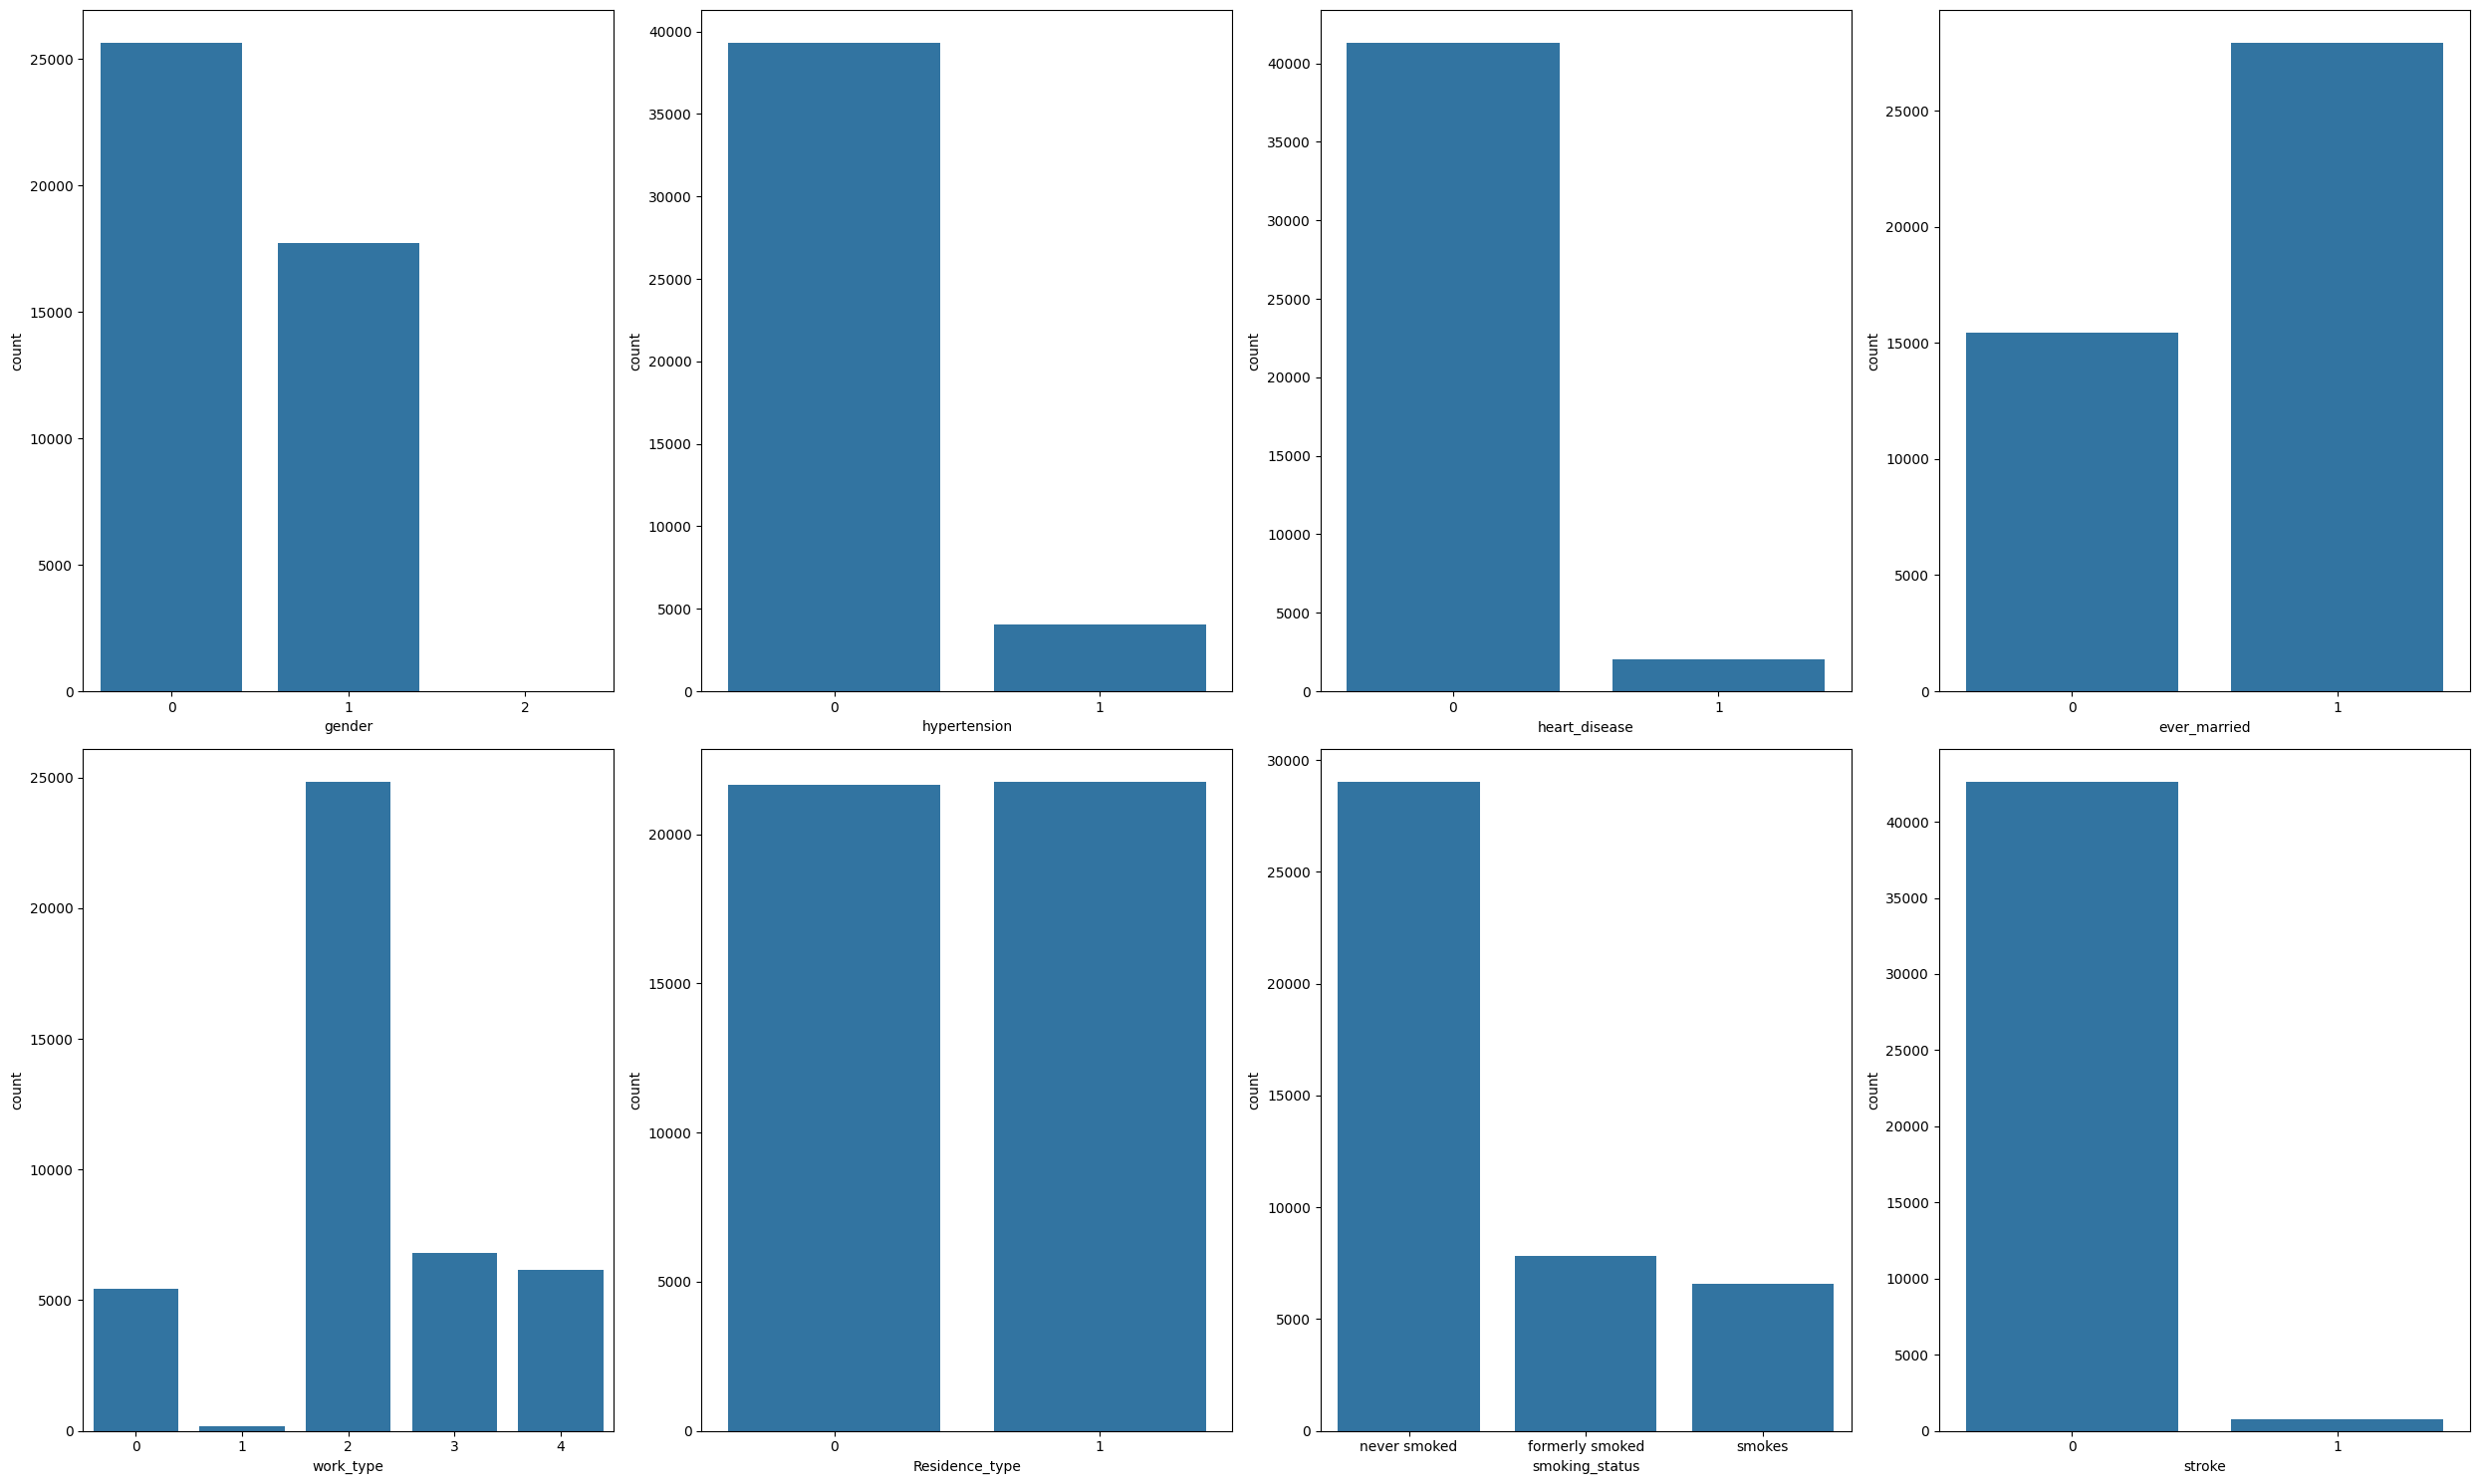

In [22]:
list_columns = df_categorical.columns.values
num_rows = 2
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(25,15))

for i, column_name in enumerate(list_columns):
    # print(i, column_name)
    sns.countplot(data=df_categorical, x=column_name, ax=axes.flatten()[i])

plt.tight_layout()
plt.show()

In [23]:
df = df.loc[:, ~df.columns.isin(['bmi_mean'])]

In [24]:
df[['smoking_status']] = df[['smoking_status']].apply(LabelEncoder().fit_transform)

C:\Users\hp\AppData\Local\Temp\ipykernel_7512\2116420600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['smoking_status']] = df[['smoking_status']].apply(LabelEncoder().fit_transform)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  object 
 4   heart_disease      43400 non-null  object 
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                43400 non-null  float64
 10  smoking_status     43400 non-null  int64  
 11  stroke             43400 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 4.0+ MB


In [26]:
df[['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'stroke']] = df[['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'stroke']].astype(int)

C:\Users\hp\AppData\Local\Temp\ipykernel_7512\3991745880.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'stroke']] = df[['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'stroke']].astype(int)


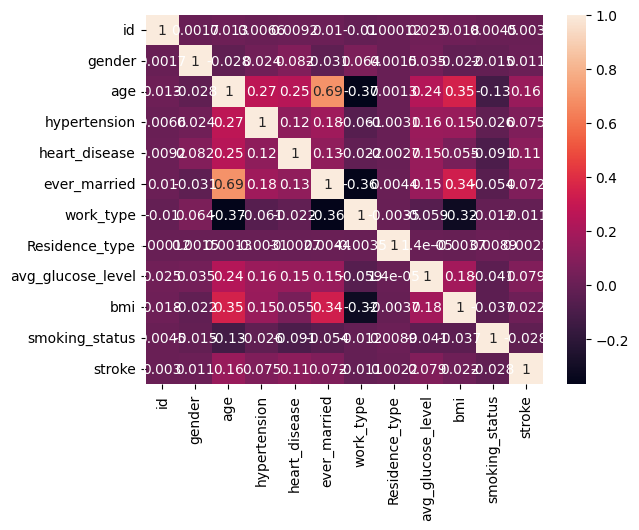

In [27]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [28]:
df = df.loc[:, ~df.columns.isin(['gender', 'id', 'work_type', 'Residence_type'])]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                43400 non-null  float64
 1   hypertension       43400 non-null  int64  
 2   heart_disease      43400 non-null  int64  
 3   ever_married       43400 non-null  int64  
 4   avg_glucose_level  43400 non-null  float64
 5   bmi                43400 non-null  float64
 6   smoking_status     43400 non-null  int64  
 7   stroke             43400 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 2.6 MB


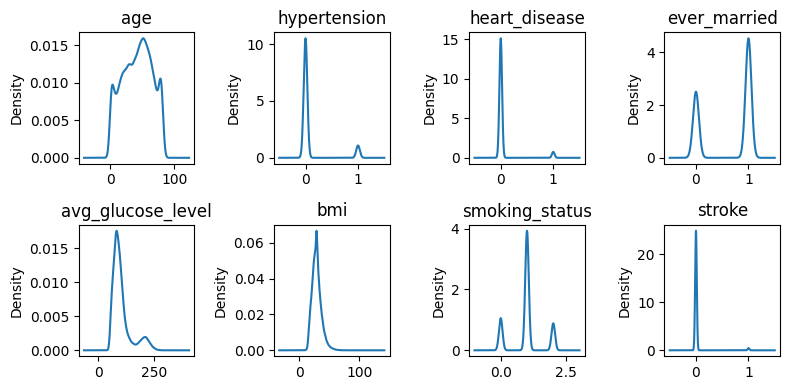

In [29]:
list_columns = list(df.columns.values)

num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(8,4))

for i, column_name in enumerate(list_columns):
    df[column_name].plot(ax=ax.flatten()[i], kind='kde')
    ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

## Splitting Data

In [30]:
# DEFINE

minority_class = 1
X = df.loc[:, ~df.columns.isin(['stroke'])].values
y = df['stroke'].values

display(X, y)

array([[  3.  ,   0.  ,   0.  , ...,  95.12,  18.  ,   1.  ],
       [ 58.  ,   1.  ,   0.  , ...,  87.96,  39.2 ,   1.  ],
       [  8.  ,   0.  ,   0.  , ..., 110.89,  17.6 ,   1.  ],
       ...,
       [ 82.  ,   1.  ,   0.  , ...,  91.94,  28.9 ,   0.  ],
       [ 40.  ,   0.  ,   0.  , ...,  99.16,  33.2 ,   1.  ],
       [ 82.  ,   0.  ,   0.  , ...,  79.48,  20.6 ,   1.  ]])

array([0, 0, 0, ..., 0, 0, 0])

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# ADASYN-Gaussian + Decision Tree

In [32]:
# Define the range of k values to test
k_values = range(2, 10)
beta_values = [0.5, 1.0, 1.5, 2.0]

# Run the evaluation (menggunakan X_train, y_train untuk menghindari data leakage)
results = evaluate_k(X_train, y_train, k_values, beta_values, minority_class=minority_class)

# Find the optimal k
best_k, best_beta, best_f1 = max(results, key=lambda item: item[2])

print(f'Optimal k: {best_k}, Optimal Beta: {best_beta}, F1 score: {best_f1:.4f}')

results

Optimal k: 2, Optimal Beta: 0.5, F1 score: 0.9757


[(2, 0.5, 0.9757362322795102),
 (2, 1.0, 0.9756493932478817),
 (2, 1.5, 0.9755192548825706),
 (2, 2.0, 0.9755626183851389),
 (3, 0.5, 0.9755192548825706),
 (3, 1.0, 0.9752594055161715),
 (3, 1.5, 0.9751945311691516),
 (3, 2.0, 0.9750648868371905),
 (4, 0.5, 0.9753459591529464),
 (4, 1.0, 0.9749353804970193),
 (4, 1.5, 0.9747198395169318),
 (4, 2.0, 0.9746767763066057),
 (5, 0.5, 0.975086484605715),
 (5, 1.0, 0.9742898710823061),
 (5, 1.5, 0.9740325863100917),
 (5, 2.0, 0.9739041356834652),
 (6, 0.5, 0.9745476757526169),
 (6, 1.0, 0.9737330642157243),
 (6, 1.5, 0.9734342200235628),
 (6, 2.0, 0.9733276512921185),
 (7, 0.5, 0.9741182907698956),
 (7, 1.0, 0.973221166365397),
 (7, 1.5, 0.9726899750710004),
 (7, 2.0, 0.9726263677868208),
 (8, 0.5, 0.9736903310482908),
 (8, 1.0, 0.972838504018972),
 (8, 1.5, 0.9719285439523684),
 (8, 2.0, 0.9719285439523684),
 (9, 0.5, 0.9733063476243837),
 (9, 1.0, 0.9720340597298099),
 (9, 1.5, 0.9714861924430467),
 (9, 2.0, 0.9708774268238056)]

Proses Adasyn-Gaussian

In [33]:
# Menggunakan X_train, y_train untuk menghindari data leakage
X_synthetic, y_synthetic, synthetic_samples = adasyn_gaussian(X_train, y_train, k=best_k, beta=best_beta, minority_class=minority_class)
print(f"Menggunakan k={best_k}, beta={best_beta}")

Menggunakan k=2, beta=0.5


In [34]:
print("Data Sintetis yang Dihasilkan:")
print(synthetic_samples)

Data Sintetis yang Dihasilkan:
[[ 7.80001097e+01  1.00015666e+00 -9.65792597e-04 ...  8.23599321e+01
   2.25004643e+01  2.00089872e+00]
 [ 7.80013335e+01  9.98730562e-01 -2.01797877e-04 ...  8.23609160e+01
   2.24997587e+01  1.99806965e+00]
 [ 7.79994691e+01  9.97170524e-01  2.88808825e-03 ...  8.23612188e+01
   2.24988178e+01  1.99893928e+00]
 ...
 [ 7.99998869e+01  1.00075054e+00 -6.86799705e-04 ...  2.40090149e+02
   2.70012314e+01  1.00072551e+00]
 [ 8.00006861e+01  9.99195810e-01 -5.43079558e-05 ...  2.40091092e+02
   2.69997772e+01  1.00093864e+00]
 [ 8.00009724e+01  1.00209471e+00  9.14344057e-04 ...  2.40089344e+02
   2.69986599e+01  1.00012022e+00]]


In [35]:
print("Jumlah Sampel Sintetis yang Dihasilkan:", len(synthetic_samples))

Jumlah Sampel Sintetis yang Dihasilkan: 14248


In [36]:
print("Jumlah Sampel di Kelas Minoritas Setelah Augmentasi:", sum(y_synthetic))

Jumlah Sampel di Kelas Minoritas Setelah Augmentasi: 14796


In [37]:
select_column = df.loc[:, ~df.columns.isin(['stroke'])]
df_x = pd.DataFrame(X_train, columns=select_column.columns)
df_x

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status
0,38.0,0.0,0.0,1.0,109.33,26.6,2.0
1,69.0,0.0,0.0,1.0,98.24,24.1,1.0
2,21.0,0.0,0.0,0.0,67.59,24.6,1.0
3,54.0,0.0,0.0,1.0,99.53,39.4,1.0
4,14.0,0.0,0.0,0.0,96.30,20.6,1.0
...,...,...,...,...,...,...,...
30375,68.0,1.0,0.0,1.0,83.57,32.9,0.0
30376,38.0,0.0,0.0,1.0,87.94,43.8,1.0
30377,67.0,0.0,0.0,1.0,125.89,32.4,1.0
30378,5.0,0.0,0.0,0.0,67.48,17.5,1.0


In [38]:
synthetic_df = pd.DataFrame(synthetic_samples, columns=df_x.columns)
synthetic_df

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status
0,78.000110,1.000157,-0.000966,-0.000717,82.359932,22.500464,2.000899
1,78.001333,0.998731,-0.000202,0.000994,82.360916,22.499759,1.998070
2,77.999469,0.997171,0.002888,0.001225,82.361219,22.498818,1.998939
3,77.999851,0.999752,-0.000902,0.002366,82.359120,22.499973,2.000400
4,78.002066,0.998608,-0.001197,-0.000715,82.360157,22.501218,2.000690
...,...,...,...,...,...,...,...
14243,80.000347,1.001075,-0.000523,1.001120,240.090005,26.998321,1.000802
14244,79.999172,1.000606,0.000845,0.999023,240.090482,27.001754,0.999964
14245,79.999887,1.000751,-0.000687,1.000035,240.090149,27.001231,1.000726
14246,80.000686,0.999196,-0.000054,1.000560,240.091092,26.999777,1.000939


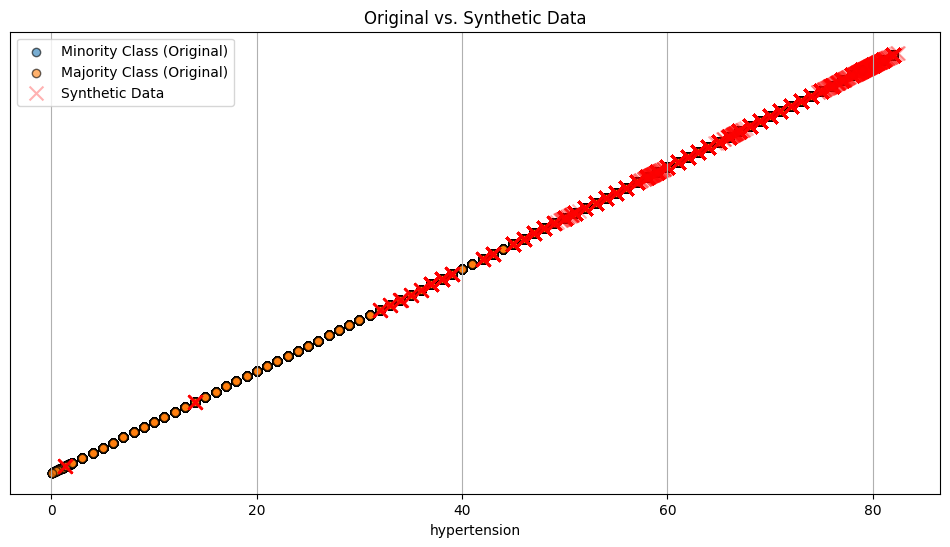

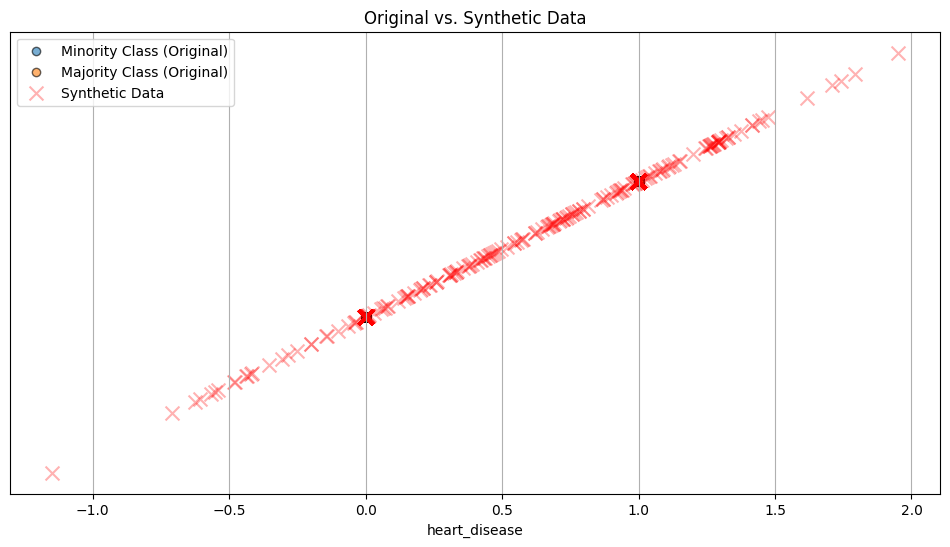

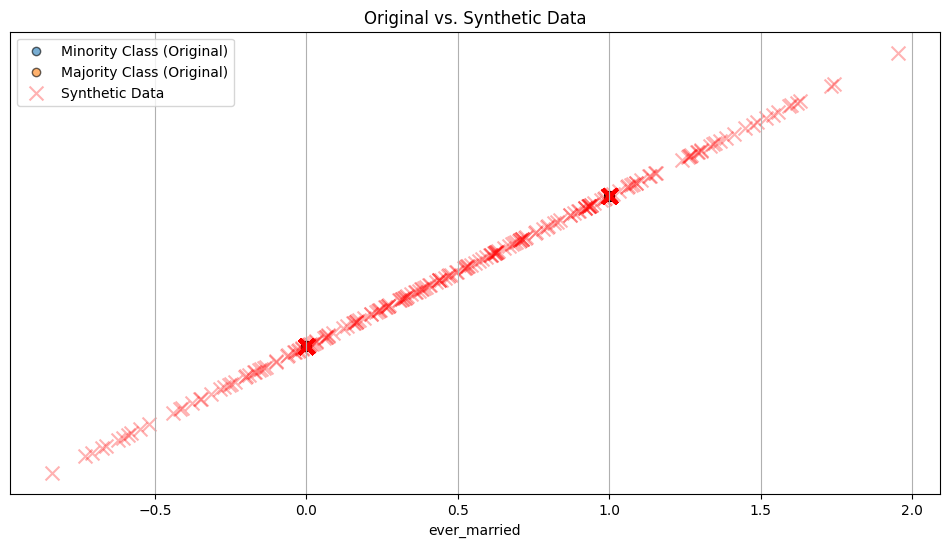

In [39]:
# Visualisasi Data Asli dan Sintetis
def plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=0):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices], X_train[y_train == 1, feature_indices], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices], X_train[y_train == 0, feature_indices], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices], synthetic_samples[:, feature_indices], label='Synthetic Data', alpha=0.3, marker='x', color='r', s=100)
    
    plt.xlabel(df.columns[feature_indices + 1])
    plt.yticks([])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

for feature_index in range(3):
    plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=feature_index)

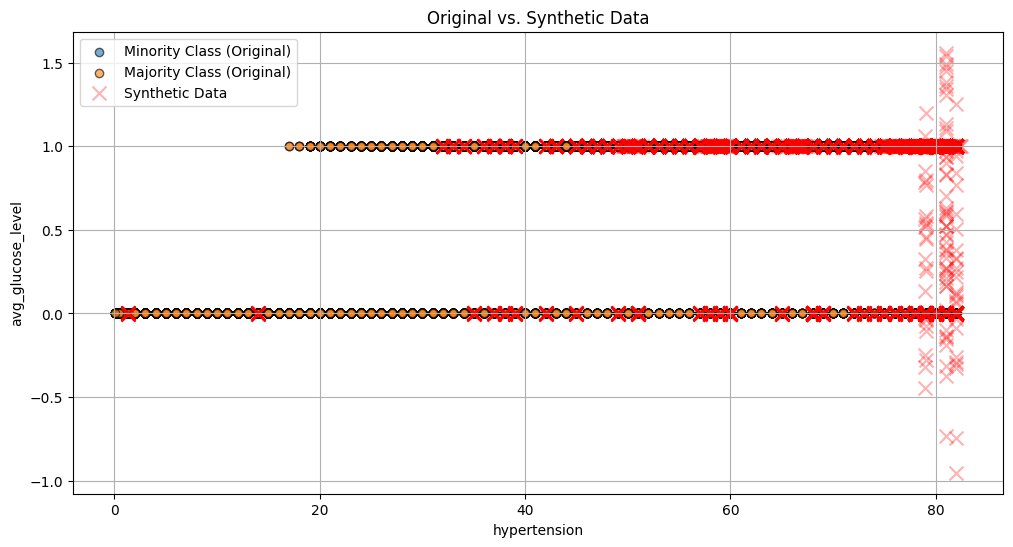

In [40]:
# Visualisasi Data Asli dan Sintetis (2D)
def plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices=[0, 1]):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices[0]], X_train[y_train== 1, feature_indices[1]], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices[0]], X_train[y_train == 0, feature_indices[1]], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices[0]], synthetic_samples[:, feature_indices[1]], label='Synthetic Data', alpha=0.3, s=100, marker='x', color='r')
    
    plt.xlabel(df.columns[feature_indices[0] + 1])
    plt.ylabel(df.columns[feature_indices[1] + 1])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

feature_indices = [0,3]
plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices)

In [41]:
display(df_x.head(5), synthetic_df.head(5))

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status
0,38.0,0.0,0.0,1.0,109.33,26.6,2.0
1,69.0,0.0,0.0,1.0,98.24,24.1,1.0
2,21.0,0.0,0.0,0.0,67.59,24.6,1.0
3,54.0,0.0,0.0,1.0,99.53,39.4,1.0
4,14.0,0.0,0.0,0.0,96.30,20.6,1.0


,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status
0,78.000110,1.000157,-0.000966,-0.000717,82.359932,22.500464,2.000899
1,78.001333,0.998731,-0.000202,0.000994,82.360916,22.499759,1.998070
2,77.999469,0.997171,0.002888,0.001225,82.361219,22.498818,1.998939
3,77.999851,0.999752,-0.000902,0.002366,82.359120,22.499973,2.000400
4,78.002066,0.998608,-0.001197,-0.000715,82.360157,22.501218,2.000690


In [42]:
synthetic_df['stroke'] = "Synthetic"
synthetic_df

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status,stroke
0,78.000110,1.000157,-0.000966,-0.000717,82.359932,22.500464,2.000899,Synthetic
1,78.001333,0.998731,-0.000202,0.000994,82.360916,22.499759,1.998070,Synthetic
2,77.999469,0.997171,0.002888,0.001225,82.361219,22.498818,1.998939,Synthetic
3,77.999851,0.999752,-0.000902,0.002366,82.359120,22.499973,2.000400,Synthetic
4,78.002066,0.998608,-0.001197,-0.000715,82.360157,22.501218,2.000690,Synthetic
...,...,...,...,...,...,...,...,...
14243,80.000347,1.001075,-0.000523,1.001120,240.090005,26.998321,1.000802,Synthetic
14244,79.999172,1.000606,0.000845,0.999023,240.090482,27.001754,0.999964,Synthetic
14245,79.999887,1.000751,-0.000687,1.000035,240.090149,27.001231,1.000726,Synthetic
14246,80.000686,0.999196,-0.000054,1.000560,240.091092,26.999777,1.000939,Synthetic


In [43]:
synthetic_df.dtypes

age                  float64
hypertension         float64
heart_disease        float64
ever_married         float64
avg_glucose_level    float64
bmi                  float64
smoking_status       float64
stroke                object
dtype: object

In [44]:
df.dtypes

age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object

In [45]:
synthetic_df[['hypertension', 'heart_disease', 'ever_married', 'smoking_status']] = synthetic_df[['hypertension', 'heart_disease', 'ever_married', 'smoking_status']].astype(int)

In [46]:
# Menggunakan data augmentasi langsung dari X_synthetic, y_synthetic
# X_synthetic sudah berisi X_train + synthetic_samples
# y_synthetic sudah berisi y_train + label minority untuk synthetic

X_train_ag = X_synthetic
y_train_ag = y_synthetic

print(f"Training set size: {len(X_train_ag)}")
print(f"Test set size: {len(X_test)}")
print(f"Training class distribution: {pd.Series(y_train_ag).value_counts().to_dict()}")

Training set size: 44628
Test set size: 13020
Training class distribution: {0: 29832, 1: 14796}


In [47]:
# Skip - sudah ditangani di cell sebelumnya
print("X_train_ag dan y_train_ag sudah disiapkan dari X_synthetic dan y_synthetic")

X_train_ag dan y_train_ag sudah disiapkan dari X_synthetic dan y_synthetic


In [48]:
# Distribusi kelas setelah augmentasi
print("Distribusi kelas training setelah ADASYN-Gaussian:")
print(pd.Series(y_train_ag).value_counts())

Distribusi kelas training setelah ADASYN-Gaussian:
0    29832
1    14796
Name: count, dtype: int64


In [49]:
# Info training data
print(f"X_train_ag shape: {X_train_ag.shape}")
print(f"y_train_ag shape: {y_train_ag.shape}")
print(f"X_test shape: {X_test.shape}")

X_train_ag shape: (44628, 7)
y_train_ag shape: (44628,)
X_test shape: (13020, 7)


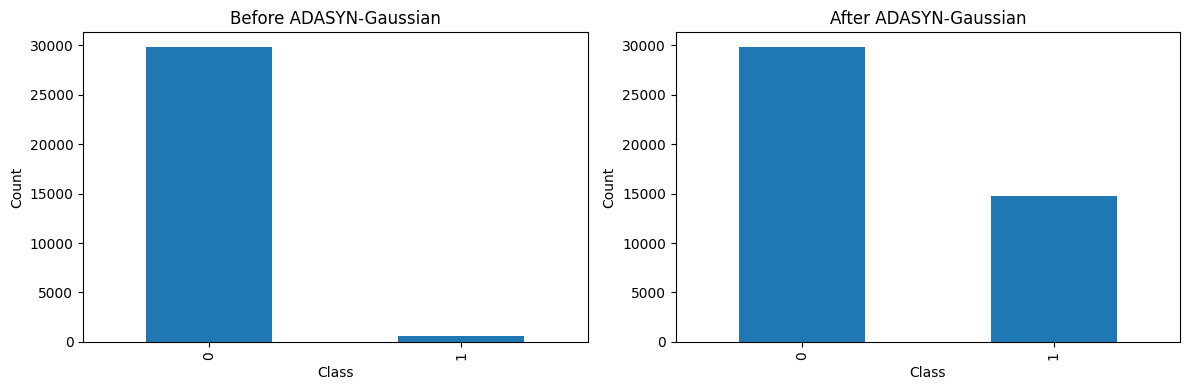

In [50]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], title='Before ADASYN-Gaussian')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
pd.Series(y_train_ag).value_counts().plot(kind='bar', ax=axes[1], title='After ADASYN-Gaussian')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [51]:
# (Skipped - distribusi sudah divisualisasikan di atas)

In [52]:
# (Skipped - sudah divisualisasikan di atas)

In [53]:
# (Skipped)

In [54]:
# (Skipped)

### Splitting (Khusus ADASYN-GAUSSIAN)

In [55]:
# (Skipped - splitting sekarang menggunakan train_test_split + augmentasi langsung)

In [56]:
# (Skipped)

In [57]:
# (Skipped)

In [58]:
# (Skipped)

In [59]:
# (Skipped)

In [60]:
# (Skipped)

In [61]:
# (Skipped)

In [62]:
# (Skipped)

In [63]:
# (Skipped)

In [64]:
# (Skipped)

In [65]:
# (Skipped)

In [66]:
# (Skipped - menggunakan X_train_ag dari X_synthetic)

In [67]:
# Test set tetap menggunakan X_test, y_test dari train_test_split
X_test_ag = X_test
y_test_ag = y_test
print(f"X_test_ag shape: {X_test_ag.shape}")

X_test_ag shape: (13020, 7)


In [68]:
# (Skipped - tidak perlu replace label lagi)

## Normalization

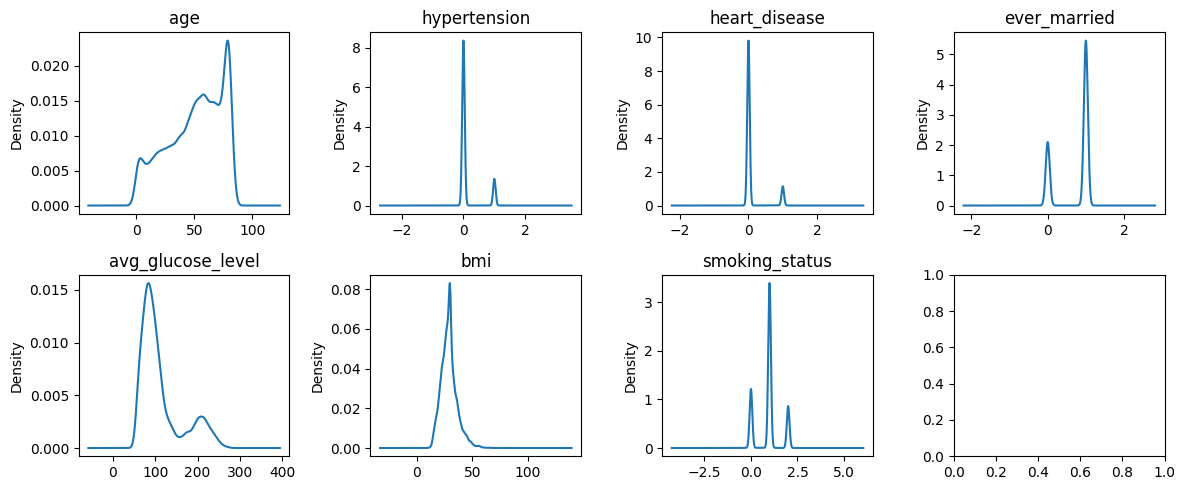

In [69]:
# Visualisasi distribusi fitur sebelum normalisasi
select_column = df.loc[:, ~df.columns.isin(['stroke'])]
df_train_viz = pd.DataFrame(X_train_ag, columns=select_column.columns)

list_columns = list(df_train_viz.columns.values)
num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, 5))

for i, column_name in enumerate(list_columns):
    if i < num_rows * num_cols:
        df_train_viz[column_name].plot(ax=ax.flatten()[i], kind='kde')
        ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

In [70]:
# Pastikan y_train_ag adalah integer
y_train_ag = np.array(y_train_ag).astype(int)
y_test_ag = np.array(y_test_ag).astype(int)
print(f"y_train_ag dtype: {y_train_ag.dtype}, y_test_ag dtype: {y_test_ag.dtype}")

y_train_ag dtype: int64, y_test_ag dtype: int64


In [71]:
from sklearn.preprocessing import QuantileTransformer

n_samples = X_train_ag.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_train_ag_scaled = transformer.fit_transform(X_train_ag)
X_test_ag_scaled = transformer.transform(X_test_ag)

print(f"X_train_ag_scaled shape: {X_train_ag_scaled.shape}")
print(f"X_test_ag_scaled shape: {X_test_ag_scaled.shape}")

X_train_ag_scaled shape: (44628, 7)
X_test_ag_scaled shape: (13020, 7)


## Classification

In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report, precision_score, 
                             recall_score, f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, ConfusionMatrixDisplay)

In [73]:
dt = DecisionTreeClassifier(random_state=42)

In [74]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_train_ag_scaled, y_train_ag)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [75]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Score: 0.9867577460695054


In [76]:
y_pred = grid_search.best_estimator_.predict(X_test_ag_scaled)

In [77]:
# (sudah di-convert sebelumnya)

In [78]:
print("=== ADASYN-Gaussian + Decision Tree ===")
print("Akurasi      :", accuracy_score(y_test_ag, y_pred))
print("Precision    :", precision_score(y_test_ag, y_pred))
print("Recall       :", recall_score(y_test_ag, y_pred))
print("F1 Score     :", f1_score(y_test_ag, y_pred))

=== ADASYN-Gaussian + Decision Tree ===
Akurasi      : 0.9827956989247312
Precision    : 0.6571428571428571
Recall       : 0.09787234042553192
F1 Score     : 0.17037037037037037


              precision    recall  f1-score   support

           0       0.98      1.00      0.99     12785
           1       0.66      0.10      0.17       235

    accuracy                           0.98     13020
   macro avg       0.82      0.55      0.58     13020
weighted avg       0.98      0.98      0.98     13020



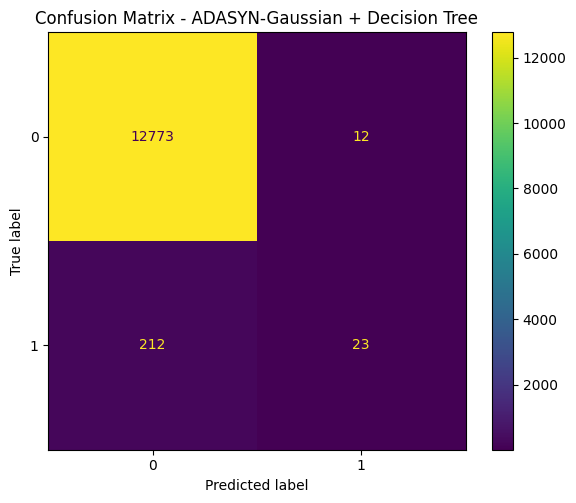

In [79]:
# Classification report
report = classification_report(y_test_ag, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred, ax=ax)
ax.set_title('Confusion Matrix - ADASYN-Gaussian + Decision Tree')
plt.tight_layout()
plt.show()

# ADASYN + Decision Tree

## ROC-AUC Curve - ADASYN-Gaussian + Decision Tree

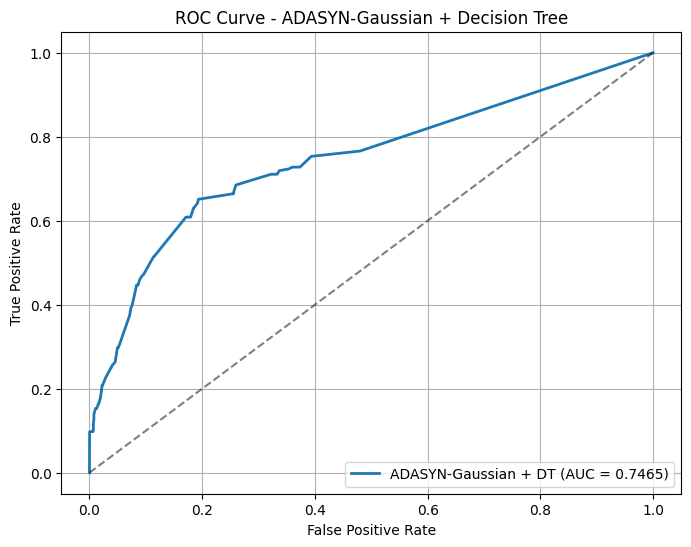

ROC-AUC Score: 0.7465


In [80]:
# ROC-AUC Curve untuk ADASYN-Gaussian + Decision Tree
y_prob_ag = grid_search.best_estimator_.predict_proba(X_test_ag_scaled)[:, 1]
fpr_ag, tpr_ag, _ = roc_curve(y_test_ag, y_prob_ag)
auc_ag = roc_auc_score(y_test_ag, y_prob_ag)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ag, tpr_ag, label=f'ADASYN-Gaussian + DT (AUC = {auc_ag:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ADASYN-Gaussian + Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {auc_ag:.4f}")

## Perbandingan Multiple Classifiers - ADASYN-Gaussian

In [81]:
# Perbandingan Multiple Classifiers dengan ADASYN-Gaussian
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_ag = []
roc_data_ag = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_ag_scaled, y_train_ag)
    y_pred_clf = clf.predict(X_test_ag_scaled)
    y_prob_clf = clf.predict_proba(X_test_ag_scaled)[:, 1]
    
    acc = accuracy_score(y_test_ag, y_pred_clf)
    prec = precision_score(y_test_ag, y_pred_clf, zero_division=0)
    rec = recall_score(y_test_ag, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test_ag, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test_ag, y_prob_clf)
    
    results_ag.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test_ag, y_prob_clf)
    roc_data_ag[name] = (fpr_clf, tpr_clf, auc)

results_ag_df = pd.DataFrame(results_ag).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===")
display(results_ag_df)

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.9843,1.0000,0.1319,0.2331,0.8786
0,Decision Tree,0.9711,0.1948,0.1915,0.1931,0.5885
5,DT (class_weight=balanced),0.9687,0.1634,0.1787,0.1707,0.5810
4,Logistic Regression,0.8639,0.0714,0.5447,0.1262,0.8331
1,Random Forest,0.9829,0.8421,0.0681,0.1260,0.7882
3,SVM,0.9727,0.1203,0.0809,0.0967,0.7091


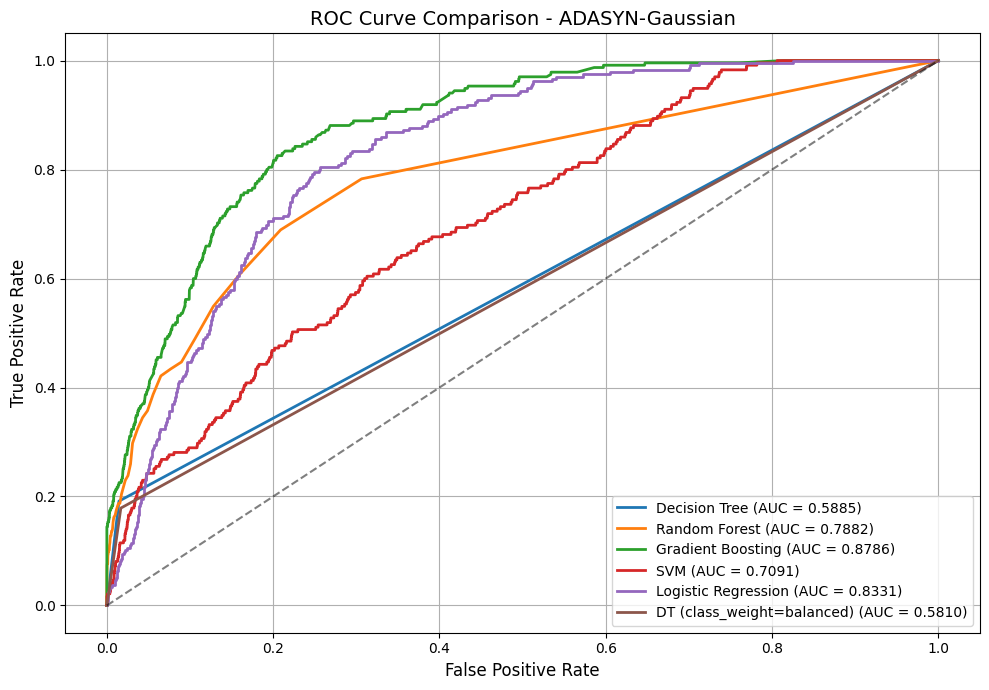

In [82]:
# ROC Curve Comparison - Semua Classifiers (ADASYN-Gaussian)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_ag.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - ADASYN-Gaussian', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

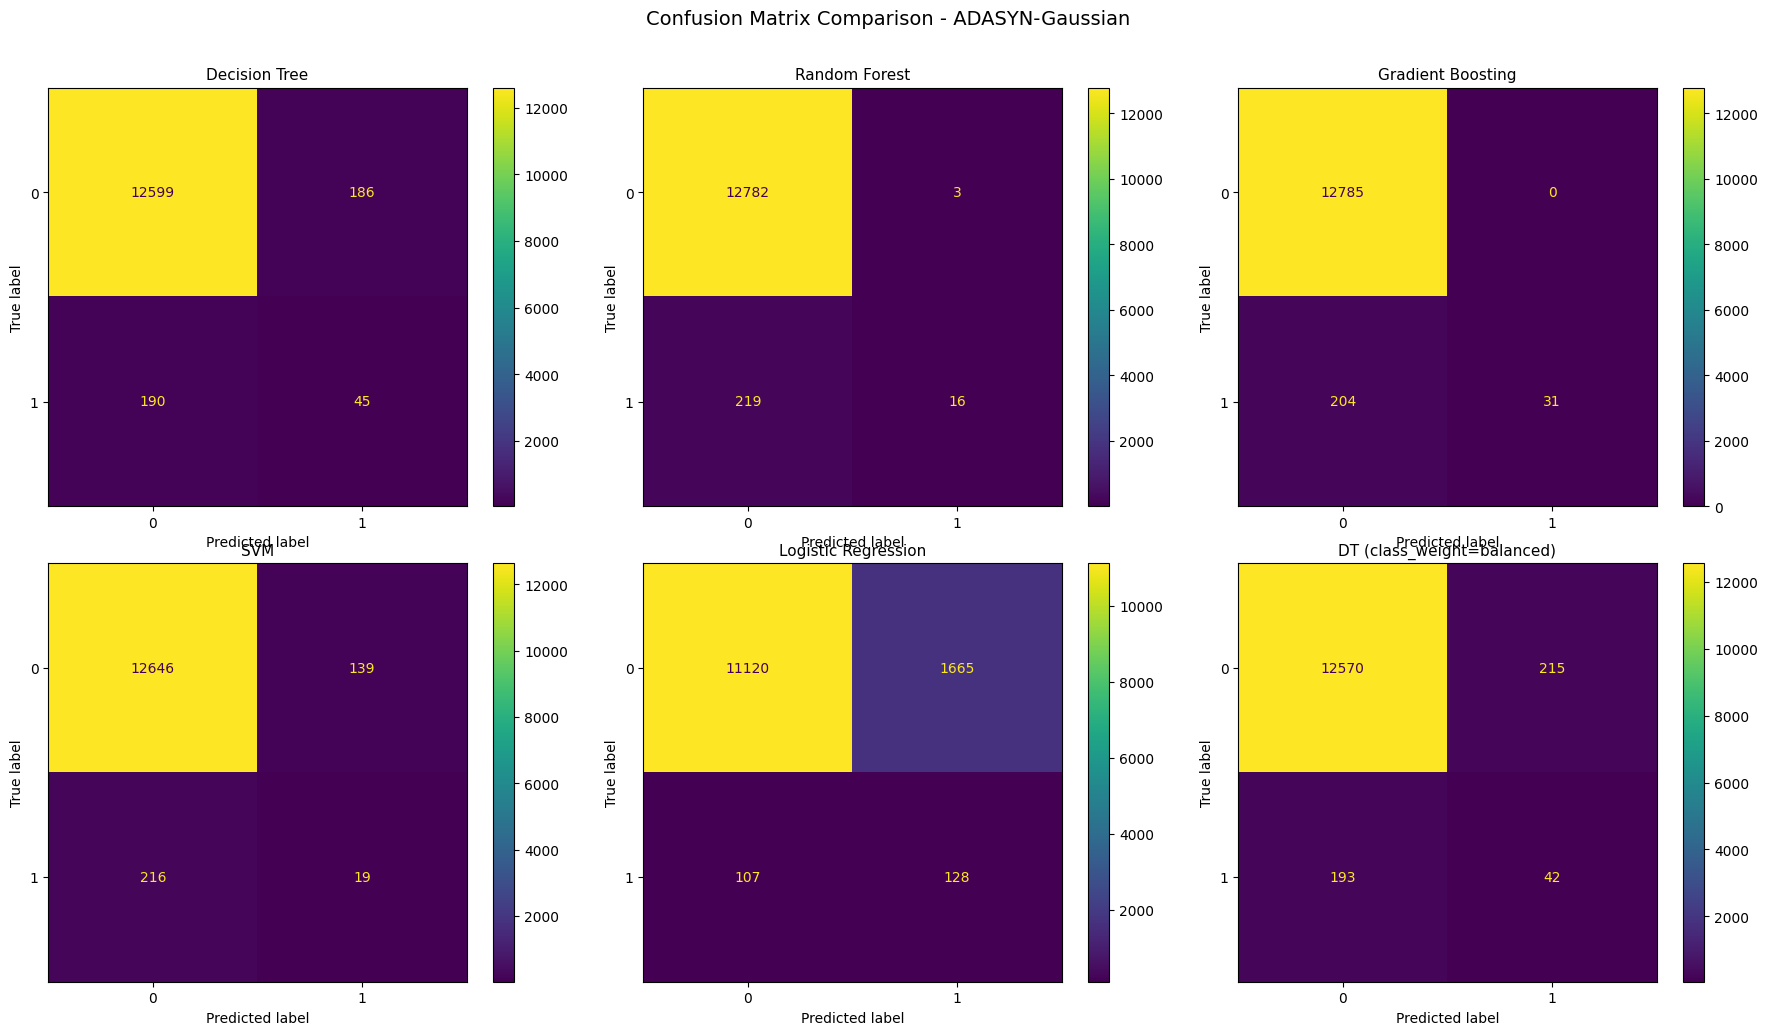

In [83]:
# Confusion Matrix Comparison - Semua Classifiers (ADASYN-Gaussian)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers.items()):
    y_pred_clf = clf.predict(X_test_ag_scaled)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - ADASYN-Gaussian', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [84]:
df

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status,stroke
0,3.0,0,0,0,95.12,18.0,1,0
1,58.0,1,0,1,87.96,39.2,1,0
2,8.0,0,0,0,110.89,17.6,1,0
3,70.0,0,0,1,69.04,35.9,0,0
4,14.0,0,0,0,161.28,19.1,1,0
...,...,...,...,...,...,...,...,...
43395,10.0,0,0,0,58.64,20.4,1,0
43396,56.0,0,0,1,213.61,55.4,0,0
43397,82.0,1,0,1,91.94,28.9,0,0
43398,40.0,0,0,1,99.16,33.2,1,0


In [85]:
display(X_train, X_test)

array([[ 38.  ,   0.  ,   0.  , ..., 109.33,  26.6 ,   2.  ],
       [ 69.  ,   0.  ,   0.  , ...,  98.24,  24.1 ,   1.  ],
       [ 21.  ,   0.  ,   0.  , ...,  67.59,  24.6 ,   1.  ],
       ...,
       [ 67.  ,   0.  ,   0.  , ..., 125.89,  32.4 ,   1.  ],
       [  5.  ,   0.  ,   0.  , ...,  67.48,  17.5 ,   1.  ],
       [ 28.  ,   0.  ,   0.  , ..., 120.76,  22.8 ,   0.  ]])

array([[  8.  ,   0.  ,   0.  , ...,  89.58,  24.7 ,   1.  ],
       [ 38.  ,   0.  ,   0.  , ..., 165.32,  31.8 ,   1.  ],
       [  1.8 ,   0.  ,   0.  , ..., 129.17,  16.2 ,   1.  ],
       ...,
       [ 15.  ,   0.  ,   0.  , ...,  90.86,  38.4 ,   1.  ],
       [ 16.  ,   0.  ,   0.  , ...,  62.68,  37.8 ,   1.  ],
       [ 66.  ,   0.  ,   0.  , ..., 180.65,  42.6 ,   1.  ]])

## ADASYN

In [86]:
from imblearn.over_sampling import ADASYN 
from collections import Counter

In [87]:
# Check class distribution before augmentation
print(f'Original class distribution: {Counter(y_train)}')

Original class distribution: Counter({np.int64(0): 29832, np.int64(1): 548})


In [88]:
# Tuning n_neighbors untuk ADASYN
from collections import Counter

best_adasyn_f1 = 0
best_adasyn_n = 2
best_X_res = None
best_y_res = None

for n_neighbors in [2, 3, 5, 7]:
    try:
        adasyn_temp = ADASYN(sampling_strategy='minority', n_neighbors=n_neighbors, random_state=42)
        X_res_temp, y_res_temp = adasyn_temp.fit_resample(X_train, y_train)
        
        # Quick evaluation with Decision Tree
        dt_temp = DecisionTreeClassifier(random_state=42)
        dt_temp.fit(X_res_temp, y_res_temp)
        y_pred_temp = dt_temp.predict(X_test)
        f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
        
        print(f"n_neighbors={n_neighbors}: distribution={Counter(y_res_temp)}, F1={f1_temp:.4f}")
        
        if f1_temp > best_adasyn_f1:
            best_adasyn_f1 = f1_temp
            best_adasyn_n = n_neighbors
            best_X_res = X_res_temp
            best_y_res = y_res_temp
    except Exception as e:
        print(f"n_neighbors={n_neighbors}: Error - {e}")

print(f"\nBest n_neighbors: {best_adasyn_n} with F1: {best_adasyn_f1:.4f}")

# Gunakan hasil terbaik
X_resampled = best_X_res
y_resampled = best_y_res

n_neighbors=2: distribution=Counter({np.int64(1): 29842, np.int64(0): 29832}), F1=0.1078
n_neighbors=3: distribution=Counter({np.int64(1): 29960, np.int64(0): 29832}), F1=0.1078
n_neighbors=5: distribution=Counter({np.int64(1): 29948, np.int64(0): 29832}), F1=0.1026
n_neighbors=7: distribution=Counter({np.int64(1): 29918, np.int64(0): 29832}), F1=0.1315

Best n_neighbors: 7 with F1: 0.1315


In [89]:
# Check class distribution after augmentation
print(f'Resampled class distribution (n_neighbors={best_adasyn_n}): {Counter(y_resampled)}')

Resampled class distribution (n_neighbors=7): Counter({np.int64(1): 29918, np.int64(0): 29832})


In [90]:
n_samples = X_resampled.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_resampled_scaled = transformer.fit_transform(X_resampled)
X_test_scaled2 = transformer.transform(X_test)


In [91]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_resampled_scaled, y_resampled)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [92]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9625941422594142


In [93]:
y_pred = grid_search.best_estimator_.predict(X_test_scaled2)

In [94]:
print("=== ADASYN + Decision Tree ===")
print("Akurasi      :", accuracy_score(y_test, y_pred))
print("Precision    :", precision_score(y_test, y_pred))
print("Recall       :", recall_score(y_test, y_pred))
print("F1 Score     :", f1_score(y_test, y_pred))

=== ADASYN + Decision Tree ===
Akurasi      : 0.9614439324116744
Precision    : 0.10850439882697947
Recall       : 0.1574468085106383
F1 Score     : 0.1284722222222222


              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12785
           1       0.11      0.16      0.13       235

    accuracy                           0.96     13020
   macro avg       0.55      0.57      0.55     13020
weighted avg       0.97      0.96      0.96     13020



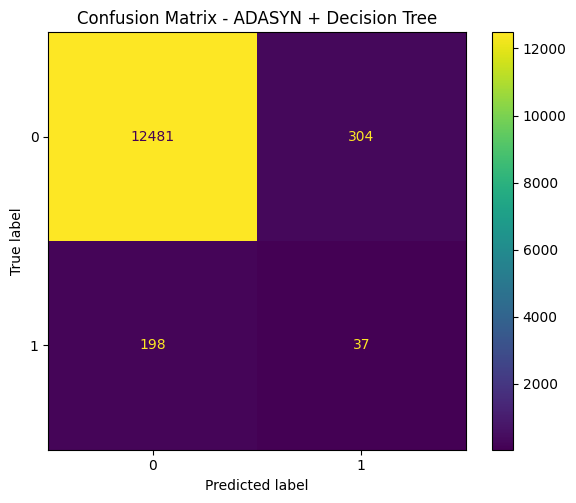

In [95]:
# Classification report
report = classification_report(y_test, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title('Confusion Matrix - ADASYN + Decision Tree')
plt.tight_layout()
plt.show()

In [96]:
# Perbandingan Multiple Classifiers dengan Standard ADASYN
classifiers_adasyn = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_adasyn = []
roc_data_adasyn = {}

for name, clf in classifiers_adasyn.items():
    print(f"Training {name}...")
    clf.fit(X_resampled_scaled, y_resampled)
    y_pred_clf = clf.predict(X_test_scaled2)
    y_prob_clf = clf.predict_proba(X_test_scaled2)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_clf)
    prec = precision_score(y_test, y_pred_clf, zero_division=0)
    rec = recall_score(y_test, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test, y_prob_clf)
    
    results_adasyn.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test, y_prob_clf)
    roc_data_adasyn[name] = (fpr_clf, tpr_clf, auc)

results_adasyn_df = pd.DataFrame(results_adasyn).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===")
display(results_adasyn_df)

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.9653,0.1682,0.2340,0.1957,0.8386
0,Decision Tree,0.9614,0.1085,0.1574,0.1285,0.5668
5,DT (class_weight=balanced),0.9604,0.0951,0.1404,0.1134,0.5579
4,Logistic Regression,0.7786,0.0590,0.7532,0.1094,0.8422
3,SVM,0.9036,0.0573,0.2809,0.0952,0.7047
1,Random Forest,0.9760,0.1188,0.0511,0.0714,0.7860


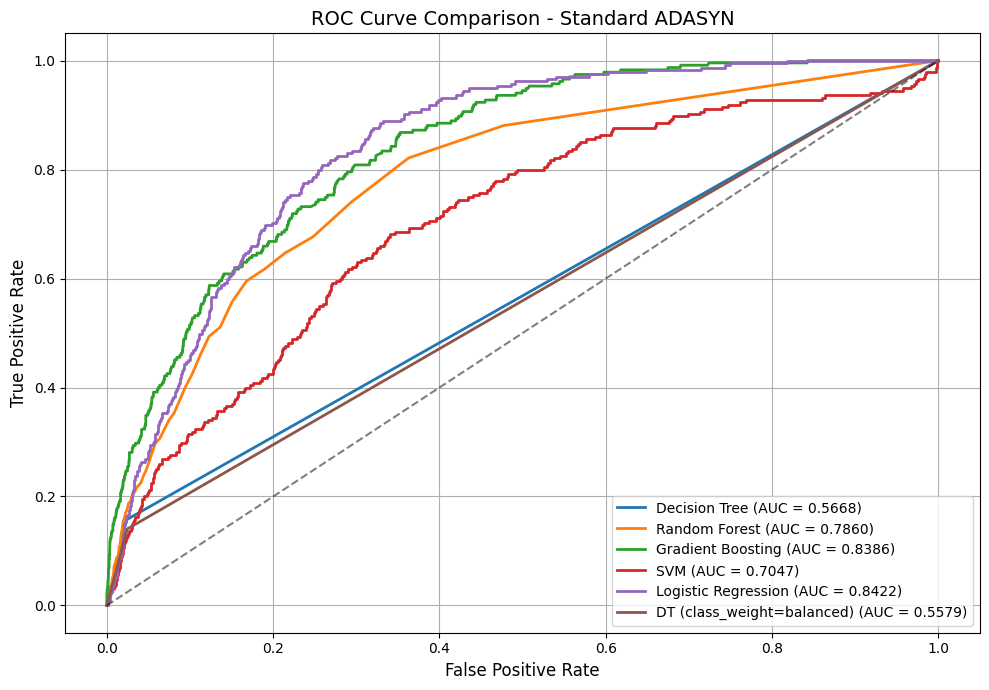

In [97]:
# ROC Curve Comparison - Semua Classifiers (Standard ADASYN)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_adasyn.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Standard ADASYN', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

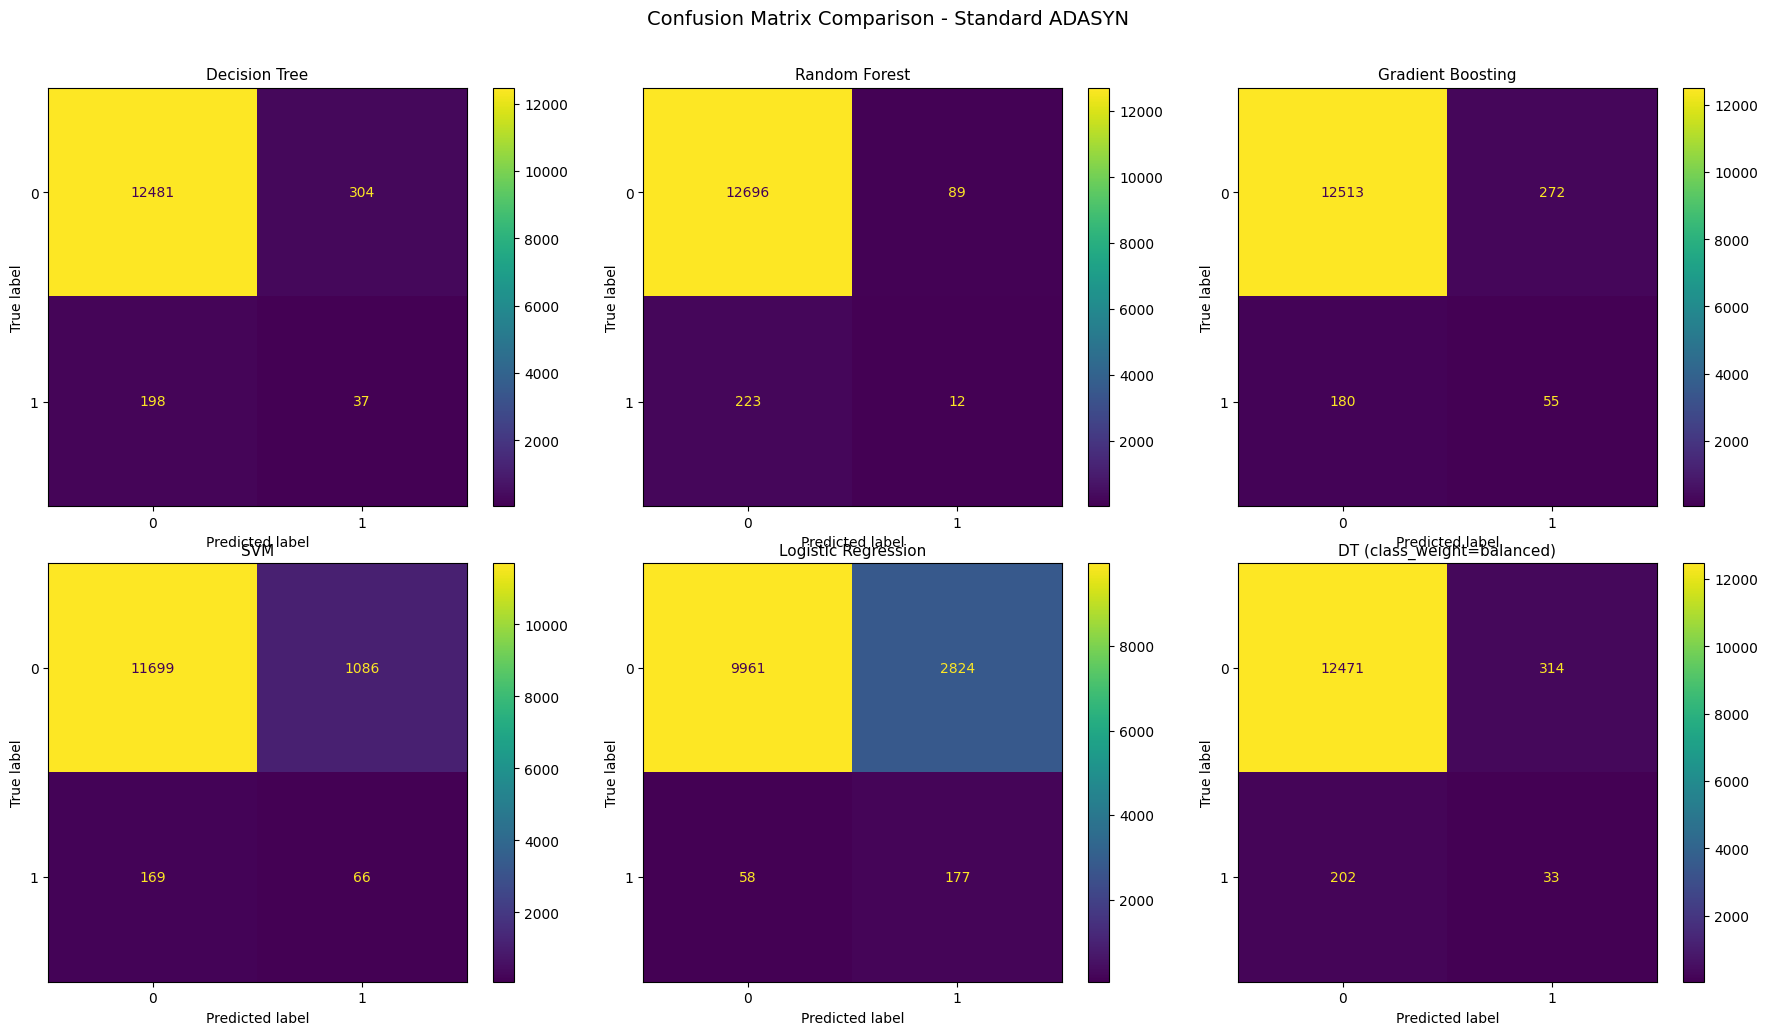

In [98]:
# Confusion Matrix Comparison - Semua Classifiers (Standard ADASYN)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers_adasyn.items()):
    y_pred_clf = clf.predict(X_test_scaled2)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - Standard ADASYN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN

In [99]:
# Tabel Perbandingan ADASYN-Gaussian vs Standard ADASYN
results_ag_df['Method'] = 'ADASYN-Gaussian'
results_adasyn_df['Method'] = 'Standard ADASYN'

comparison_df = pd.concat([results_ag_df, results_adasyn_df], ignore_index=True)
comparison_df = comparison_df[['Method', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
comparison_df = comparison_df.sort_values(['Model', 'Method'])

print("=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===")
display(comparison_df)

# Highlight best F1 per method
print("\n--- Best Model per Method ---")
for method in ['ADASYN-Gaussian', 'Standard ADASYN']:
    best = comparison_df[comparison_df['Method'] == method].sort_values('F1 Score', ascending=False).iloc[0]
    print(f"{method}: {best['Model']} (F1={best['F1 Score']}, AUC={best['ROC-AUC']})")

=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===


,Method,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,ADASYN-Gaussian,DT (class_weight=balanced),0.9687,0.1634,0.1787,0.1707,0.5810
8,Standard ADASYN,DT (class_weight=balanced),0.9604,0.0951,0.1404,0.1134,0.5579
1,ADASYN-Gaussian,Decision Tree,0.9711,0.1948,0.1915,0.1931,0.5885
7,Standard ADASYN,Decision Tree,0.9614,0.1085,0.1574,0.1285,0.5668
0,ADASYN-Gaussian,Gradient Boosting,0.9843,1.0000,0.1319,0.2331,0.8786
6,Standard ADASYN,Gradient Boosting,0.9653,0.1682,0.2340,0.1957,0.8386
3,ADASYN-Gaussian,Logistic Regression,0.8639,0.0714,0.5447,0.1262,0.8331
9,Standard ADASYN,Logistic Regression,0.7786,0.0590,0.7532,0.1094,0.8422
4,ADASYN-Gaussian,Random Forest,0.9829,0.8421,0.0681,0.1260,0.7882
11,Standard ADASYN,Random Forest,0.9760,0.1188,0.0511,0.0714,0.7860



--- Best Model per Method ---
ADASYN-Gaussian: Gradient Boosting (F1=0.2331, AUC=0.8786)
Standard ADASYN: Gradient Boosting (F1=0.1957, AUC=0.8386)


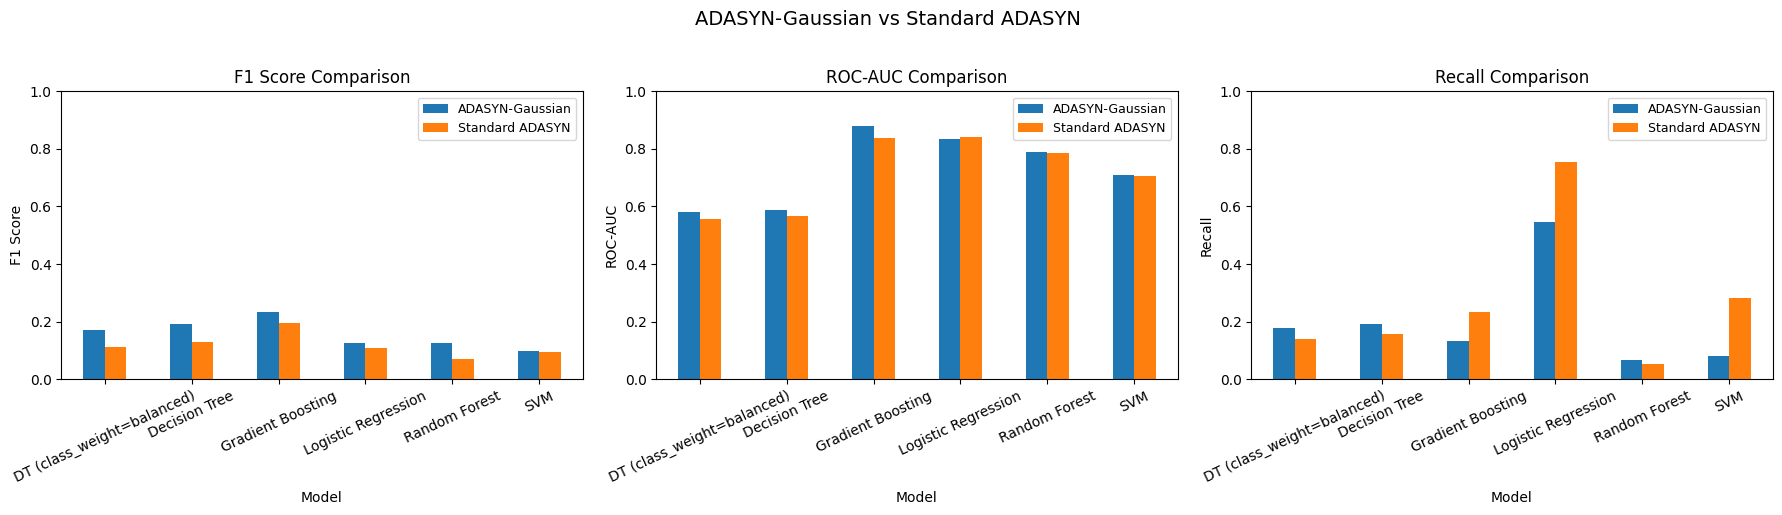

In [100]:
# Visualisasi Bar Chart Perbandingan F1 Score per Model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['F1 Score', 'ROC-AUC', 'Recall']
for i, metric in enumerate(metrics_to_plot):
    pivot = comparison_df.pivot(index='Model', columns='Method', values=metric)
    pivot.plot(kind='bar', ax=axes[i], rot=25)
    axes[i].set_title(f'{metric} Comparison', fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].legend(fontsize=9)
    axes[i].set_ylim(0, 1)

plt.suptitle('ADASYN-Gaussian vs Standard ADASYN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()